In [1]:
from truchet_viewer import show_tiles, multiscale_truchet
from truchet_viewer.tiler import value_chart
from truchet_viewer.helpers import make_bgfg

from truchet_viewer.n6 import n6_circles, n6_tiles, n6_connected, n6_filled, n6_lattice, n6_strokes, n6_weird
from truchet_viewer.carlson import carlson_tiles

In [2]:
n6_tiles[:5]

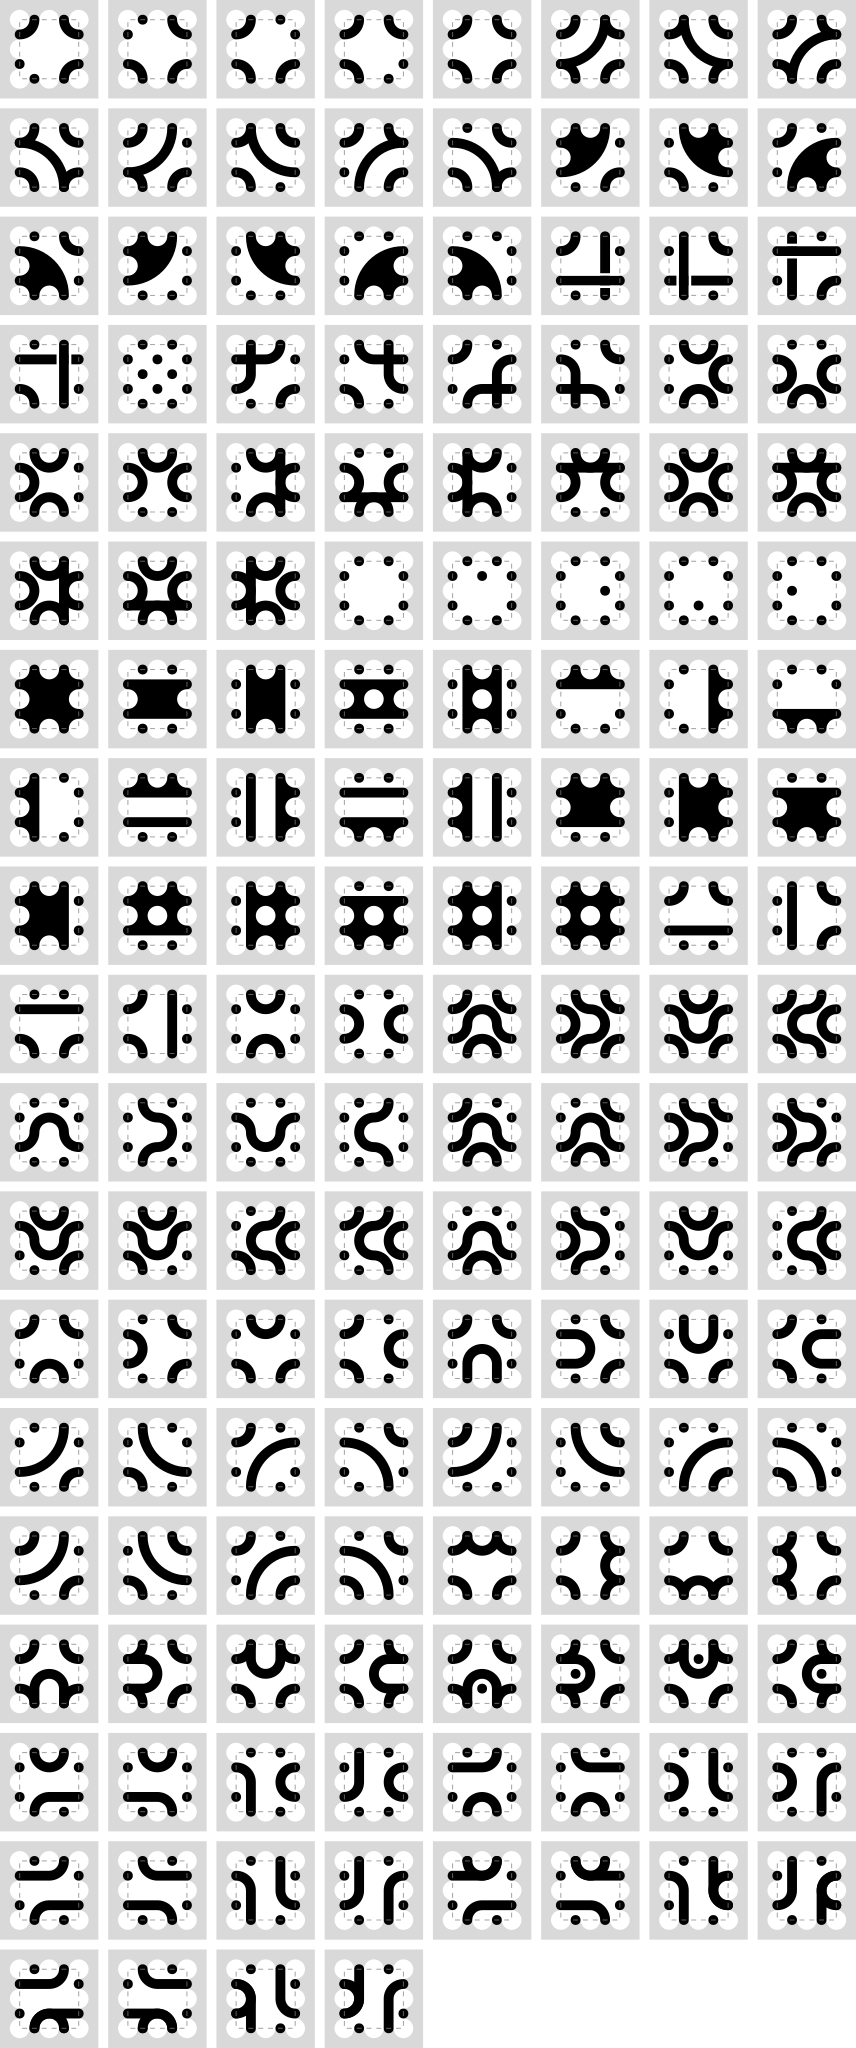

In [3]:
show_tiles(n6_tiles)

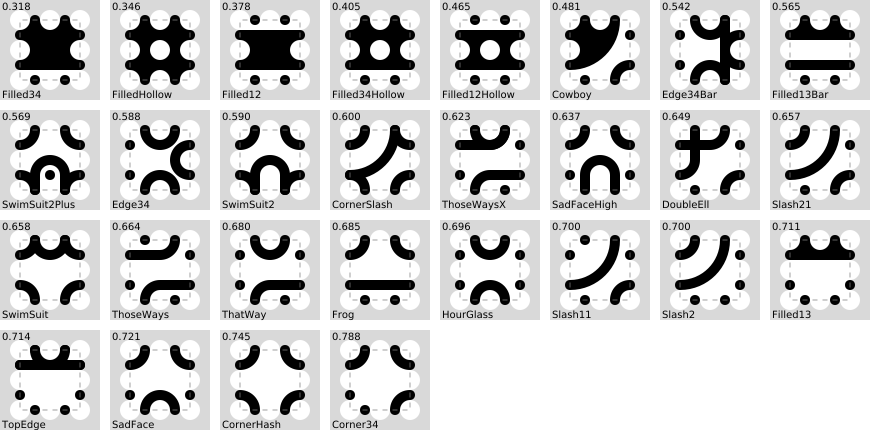

In [4]:
show_tiles(n6_circles, with_value=True, with_name=True, only_one=True, size=100, width=900)

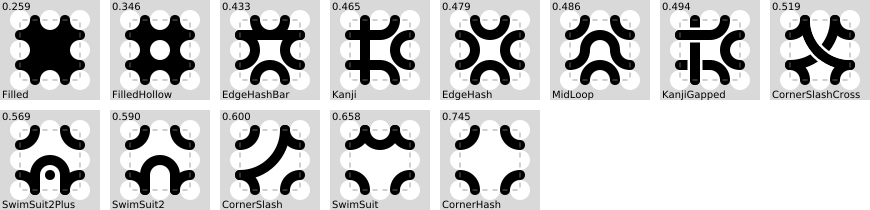

In [5]:
show_tiles(n6_connected, with_value=True, with_name=True, only_one=True, size=100, width=900)

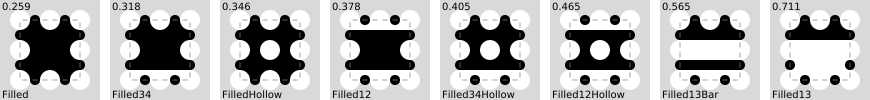

In [6]:
show_tiles(n6_filled, with_value=True, with_name=True, only_one=True, size=100, width=1200)

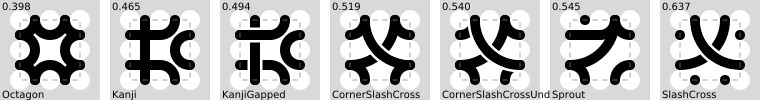

In [7]:
show_tiles(n6_weird, with_value=True, with_name=True, only_one=True, size=100, width=1200)

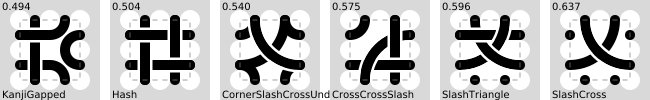

In [8]:
show_tiles(n6_lattice, with_value=True, with_name=True, only_one=True, size=100, width=1200)

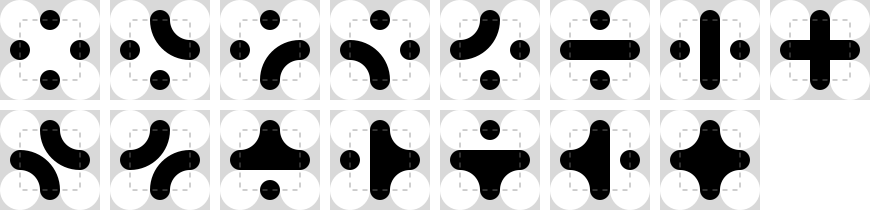

In [9]:
show_tiles(carlson_tiles)

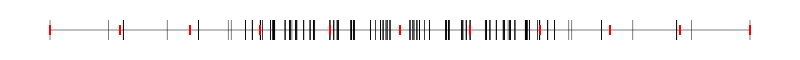

In [10]:
value_chart(n6_tiles, inverted=True)

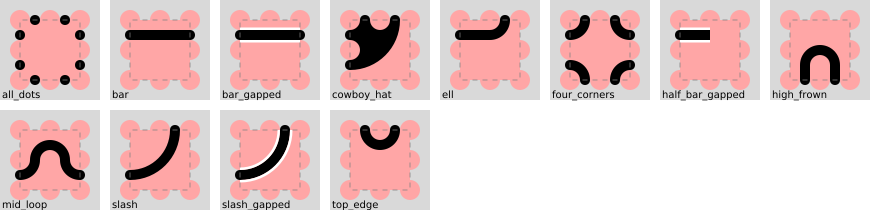

In [11]:
show_tiles(n6_strokes, with_name=True)

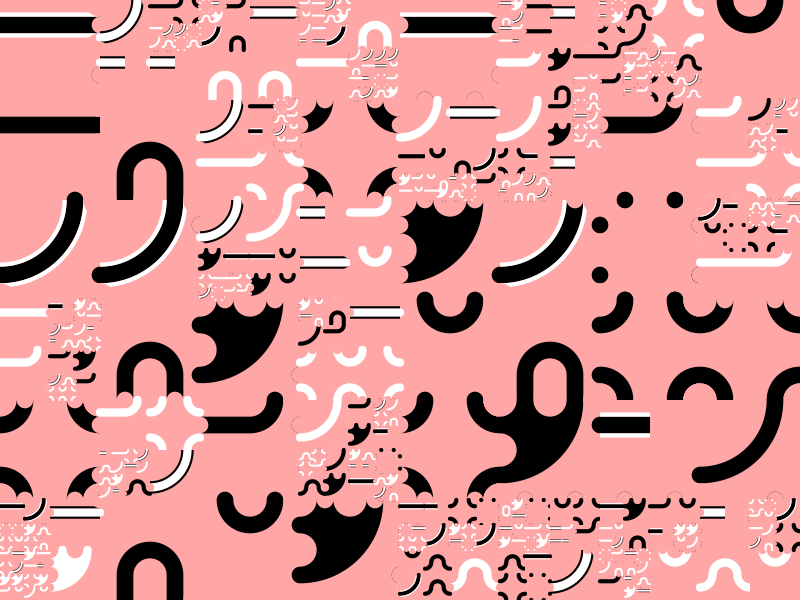

In [12]:
multiscale_truchet(tiles=n6_strokes, width=800, height=600, tilew=100, nlayers=4, chance=.45, grid=False, seed=18)

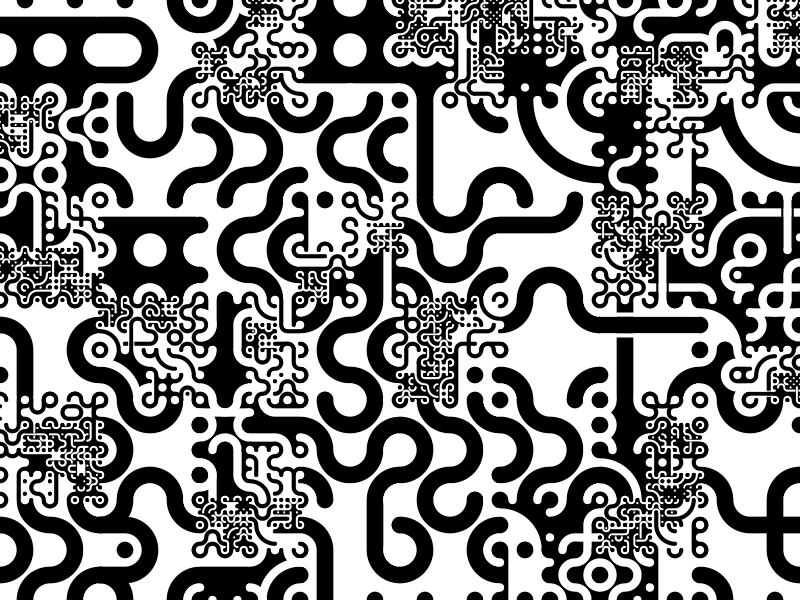

In [13]:
multiscale_truchet(tiles=n6_tiles, width=800, height=600, tilew=100, nlayers=4, chance=.45, grid=False, seed=18)

In [14]:
multiscale_truchet(
    tiles=n6_circles, width=2160, height=3840, tilew=240, nlayers=4, chance=.4, bg="#335495", fg="#243b6a", 
    format="png", output="~/wallpaper/tru6.png",
)

In [15]:
multiscale_truchet(
    tiles=n6_circles, width=2872, height=5108, tilew=300, nlayers=3, chance=.4, bg="#335495", fg="#243b6a", 
    format="png", output="~/wallpaper/tru6_large.png",
)

In [16]:
make_bgfg((.75), (.55, .35), (.3))

{'bg': (0.5499999999999999, 0.41500000000000004, 0.685),
 'fg': (0.34999999999999987, 0.245, 0.45499999999999996)}

In [17]:
make_bgfg( (.55, .35), (.55, .35), (.3))

{'bg': (0.41500000000000004, 0.6039999999999999, 0.685),
 'fg': (0.245, 0.45499999999999996, 0.266)}

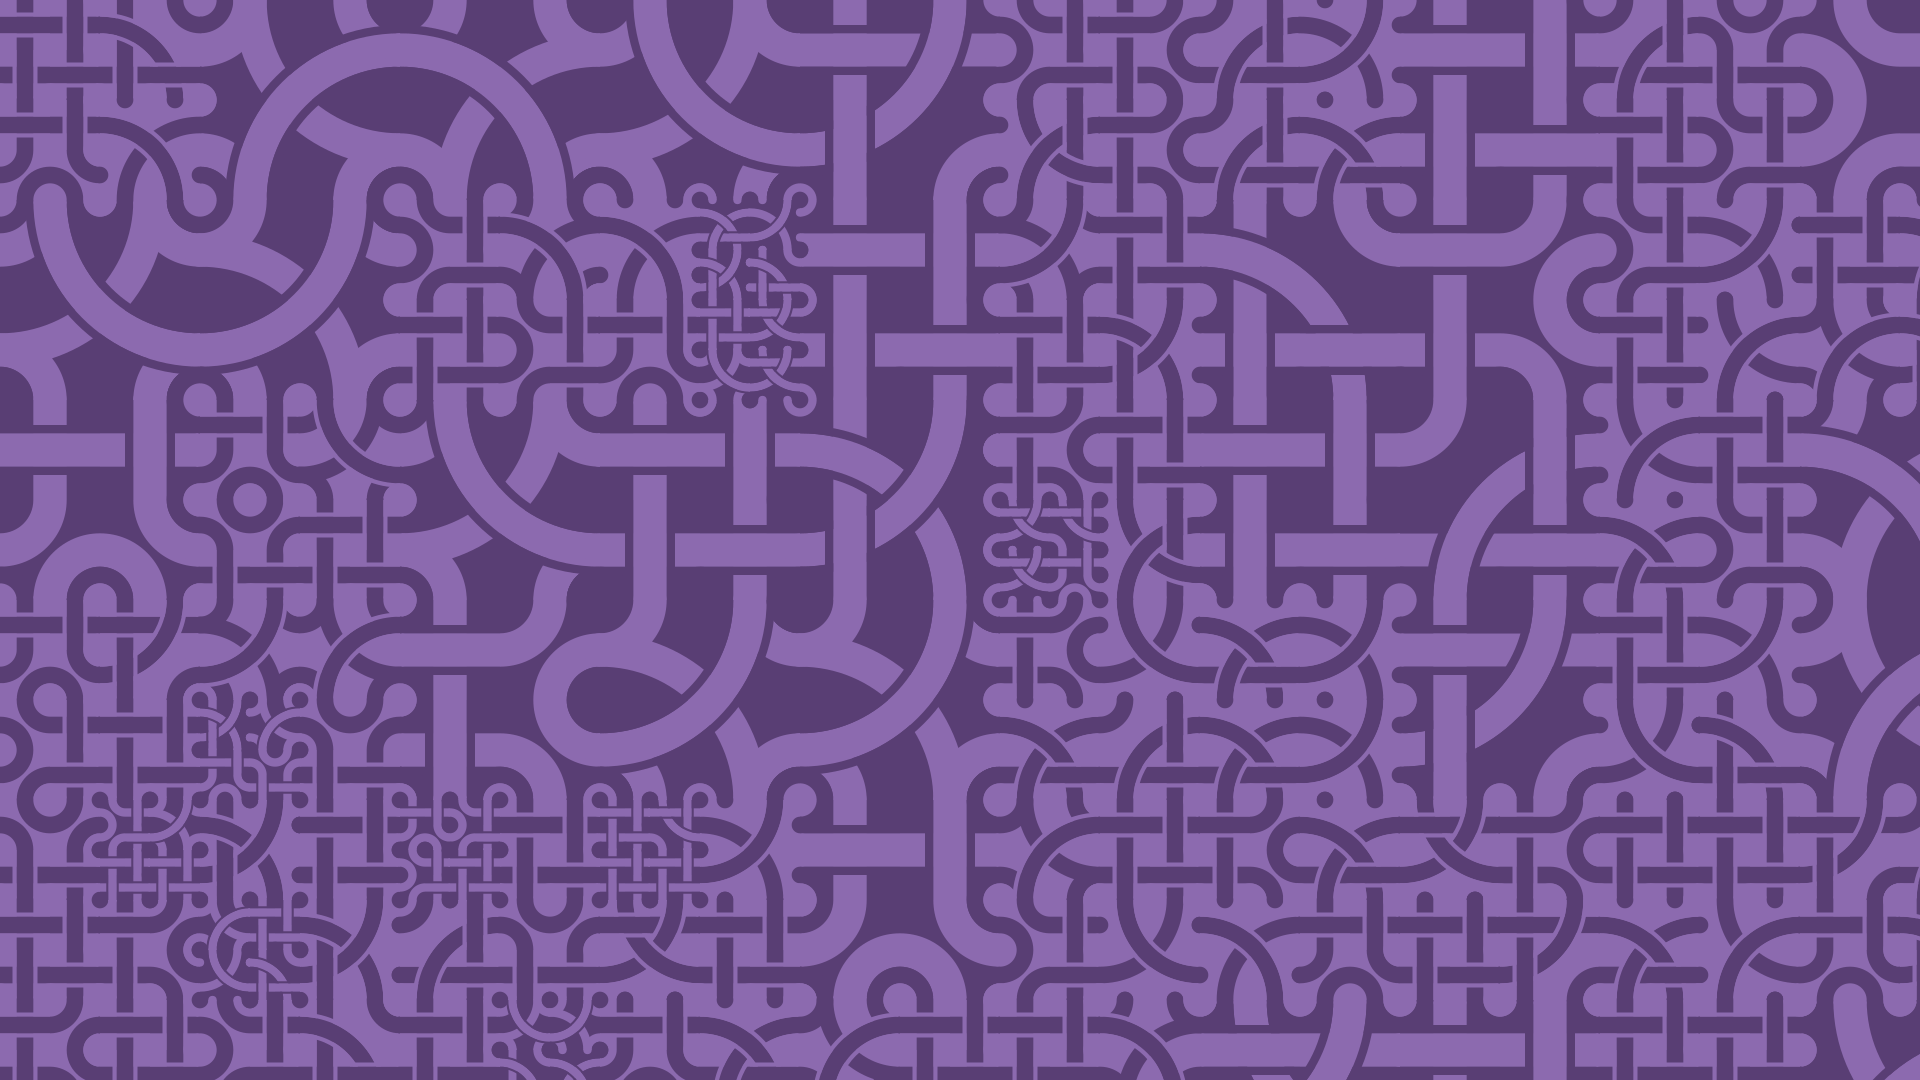

In [18]:
multiscale_truchet(
        tiles=n6_lattice, width=1920, height=1080, tilew=400, nlayers=5, 
        chance=(lambda x, y, size, ilayer: [.9, .5, .1, .1][ilayer]), 
        seed=102, **make_bgfg((0.75), (.55, .35), (.3)), format="png",
    )

In [19]:
for seed in range(100):
    multiscale_truchet(
        tiles=n6_lattice, width=1920, height=1080, tilew=400, nlayers=3, 
        chance=(lambda x, y, size, ilayer: [.9, .5][ilayer]), 
        seed=seed, **make_bgfg((.35), (.50, .45), (.3)), format="png",
        output=f"~/wallpaper/dwn/zoomy/truchet_{seed:02d}.png",
    )

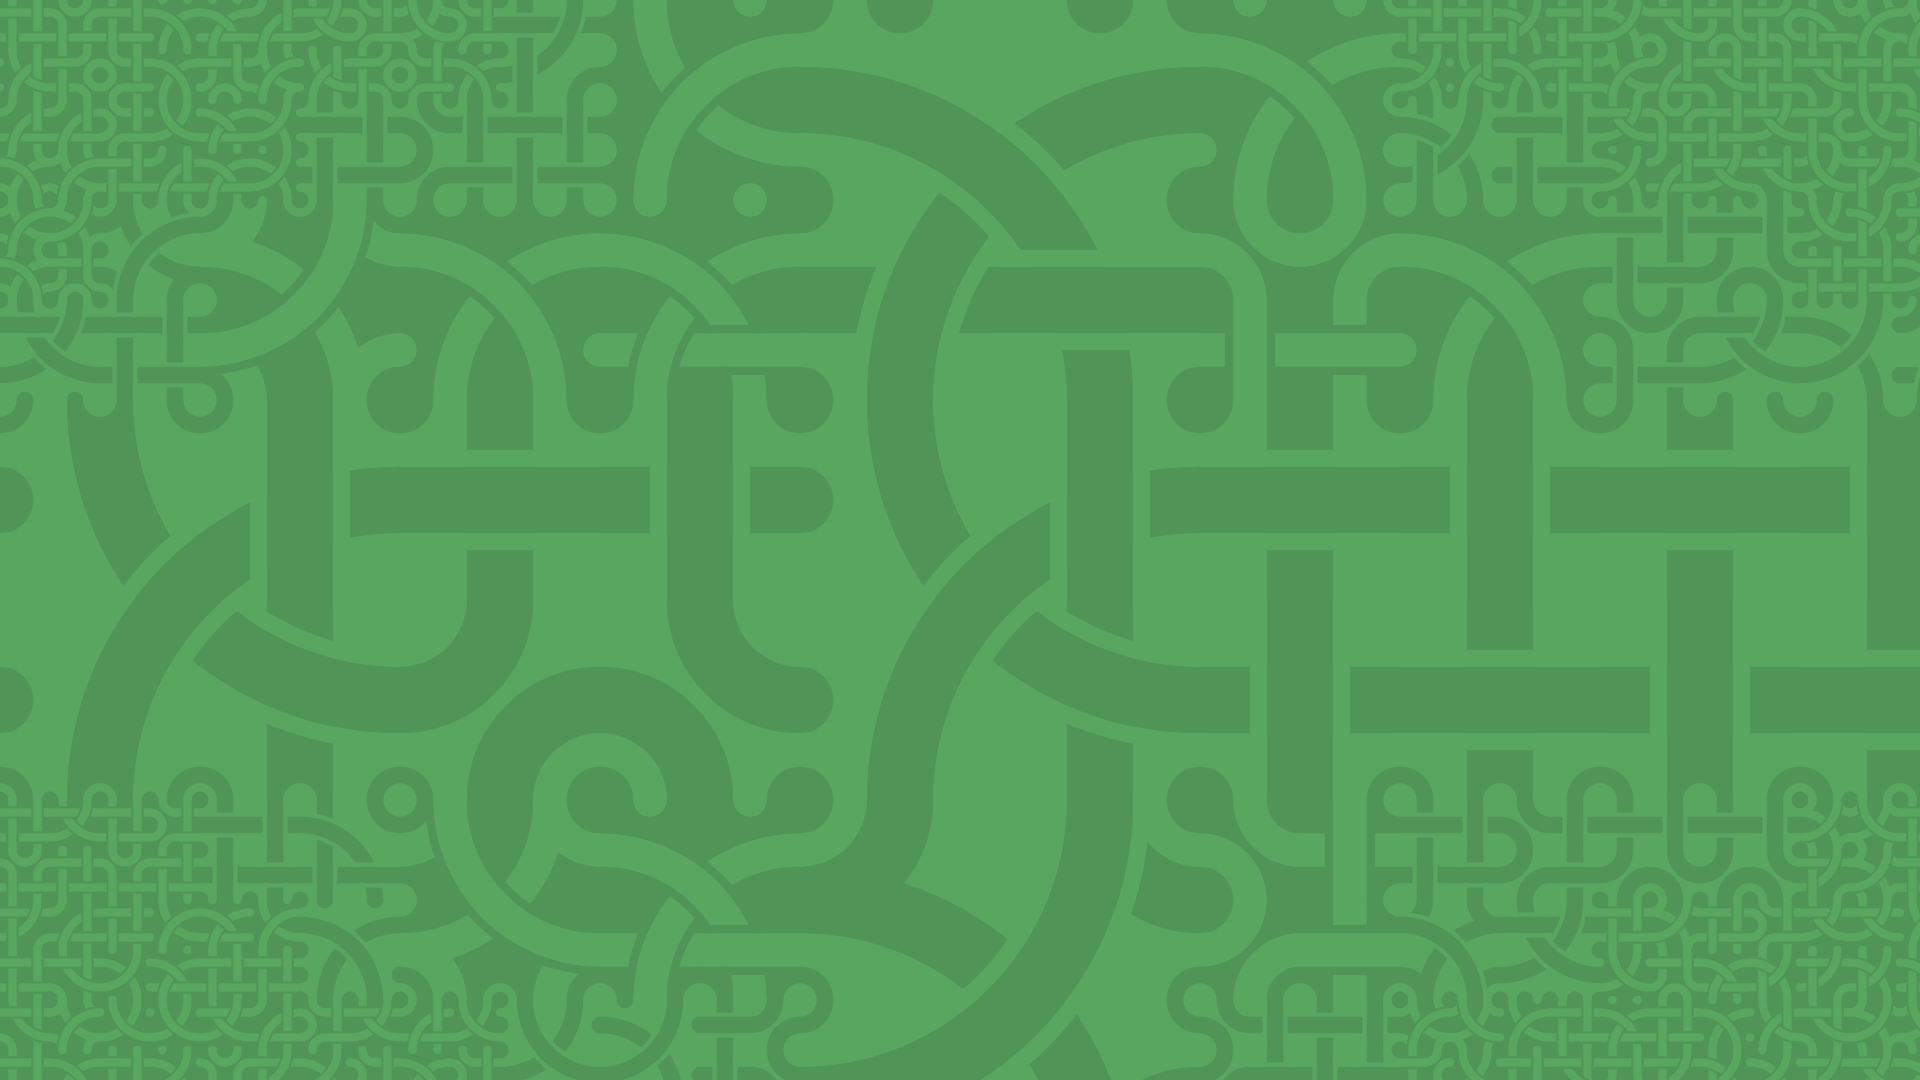

In [20]:
from math import sqrt
def ring_chance(x, y, size, ilayer):
    dist_from_center = abs(x - .5) + abs(y - .5)
    thresh = [.5, .6, .7, .8][ilayer]
    return float(dist_from_center > thresh)

multiscale_truchet(
    tiles=n6_lattice, width=1920, height=1080, tilew=400, nlayers=4, 
    chance=ring_chance, 
    seed=102, **make_bgfg((.35), (.50, .45), (.3)), format="png",
    #output="/dwn/zoomarch_truchet.png",        
)

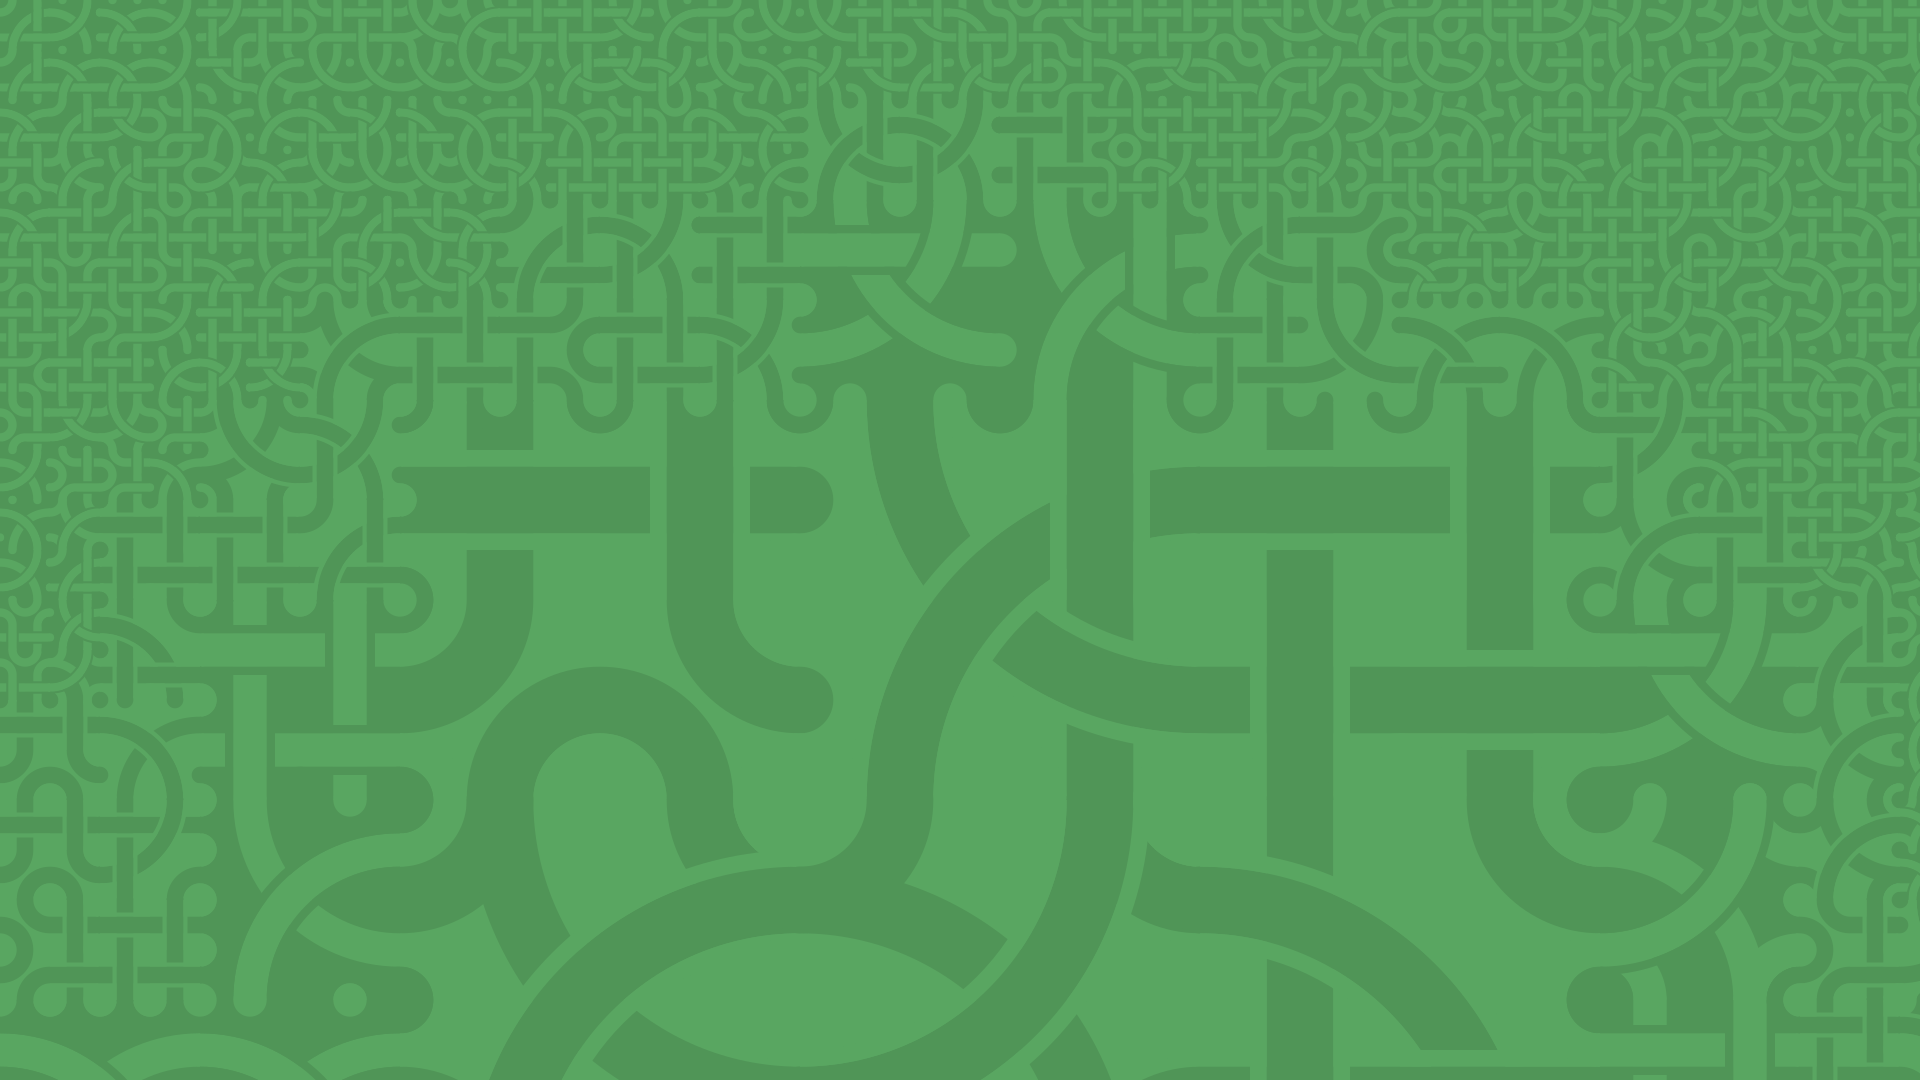

In [21]:
def arch_distance(x, y):
    return sqrt(((x - .5)/.75)**2 + ((y - 1)/1.25)**2)

def arch_chance(x, y, size, ilayer):
    thresh = [.5, .6, .7, .8][ilayer]
    return float(arch_distance(x, y) > thresh)

multiscale_truchet(
    tiles=n6_lattice, width=1920, height=1080, tilew=400, nlayers=4, 
    chance=arch_chance, 
    seed=102, **make_bgfg((.35), (.50, .45), (.3)), format="png",
    #output="/dwn/zoomarch_truchet.png",        
)

In [22]:
import random
def tile_chooser(ux, uy, uw, ilayer):
    dist = arch_distance(ux, uy)
    tiles = n6_lattice if dist < .88 else n6_circles
    return random.choice(tiles)

multiscale_truchet(
    tile_chooser=tile_chooser, 
    width=1920, height=1080, tilew=400, nlayers=4, 
    chance=arch_chance,
    **make_bgfg((.40), (.50, .45), (.3)), seed=18, format="png", 
    output="~/wallpaper/dwn/zoom.png",
)